# Prediksi Resistensi Antibiotik terhadap Bakteri

## Abstraksi

## Import Library

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modeling
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## Explanatory Data Analysis

### Mengunggah Dataset

In [ ]:

df = pd.read_csv('BVBRC_genome_amr.csv')
df.head(5)


Shape: (1284851, 21)

Phenotype distribution:
Resistant Phenotype
Susceptible                   465198
Resistant                     218263
Intermediate                   18485
Nonsusceptible                  2840
Reduced Susceptibility           116
Susceptible-dose dependent         7
Name: count, dtype: int64


### Informasi Dataset

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1284851 entries, 0 to 1284850
Data columns (total 21 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   Taxon ID                          1284851 non-null  int64  
 1   Genome ID                         1284851 non-null  float64
 2   Genome Name                       1284851 non-null  str    
 3   Antibiotic                        1284851 non-null  str    
 4   Resistant Phenotype               704909 non-null   str    
 5   Measurement                       817590 non-null   str    
 6   Measurement Sign                  376963 non-null   str    
 7   Measurement Value                 819789 non-null   str    
 8   Measurement Unit                  816006 non-null   str    
 9   Laboratory Typing Method          1163637 non-null  str    
 10  Laboratory Typing Method Version  48717 non-null    str    
 11  Laboratory Typing Platform        293559 non-nul

In [9]:
df.describe(include='all')

,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
count,1.284851e+06,1.284851e+06,1284851,1284851,704909,817590,376963,819789,816006,1163637,...,293559,494088,757266,576629.000000,0.0,0.0,0.0,1284851,30116.0,1144137
unique,NaN,NaN,120712,183,6,1790,5,1535,2,10,...,15,17,30,NaN,NaN,NaN,NaN,1,17.0,293
top,NaN,NaN,Escherichia coli 131,ciprofloxacin,Susceptible,<=1,<=,1,mg/L,Broth dilution,...,Sensititre,Thermo Fisher Scientific,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,28784677.0,38052776
freq,NaN,NaN,2516,66089,465198,42574,185452,84787,802621,526760,...,131948,159316,459727,NaN,NaN,NaN,NaN,1284851,13200.0,119317
mean,5.466363e+04,5.518352e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2017.780386,NaN,NaN,NaN,NaN,NaN,NaN
std,2.555634e+05,2.566549e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.140474,NaN,NaN,NaN,NaN,NaN,NaN
min,1.950000e+02,1.951007e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2007.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.620000e+02,5.625879e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.280000e+03,1.280920e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.773000e+03,1.773333e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)
Resistant Phenotype,579942,45.14
Measurement,467261,36.37
Measurement Sign,907888,70.66
Measurement Value,465062,36.20
Measurement Unit,468845,36.49
Laboratory Typing Method,121214,9.43
Laboratory Typing Method Version,1236134,96.21
Laboratory Typing Platform,991292,77.15
Vendor,790763,61.55
Testing Standard,527585,41.06


# 2. Assign Resistance Phenotypes to a Label

# 3. Train/Test Split, 80% untuk Training, Sisanya untuk Testing

In [7]:
X = df[['bacteria_enc', 'antibiotic_enc', 'evidence_enc']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")

KeyError: "None of [Index(['bacteria_enc', 'antibiotic_enc', 'evidence_enc'], dtype='str')] are in the [columns]"

# 4. Model Training

# 5. Evaluate On Test Set

# 6. Confusion Matrix

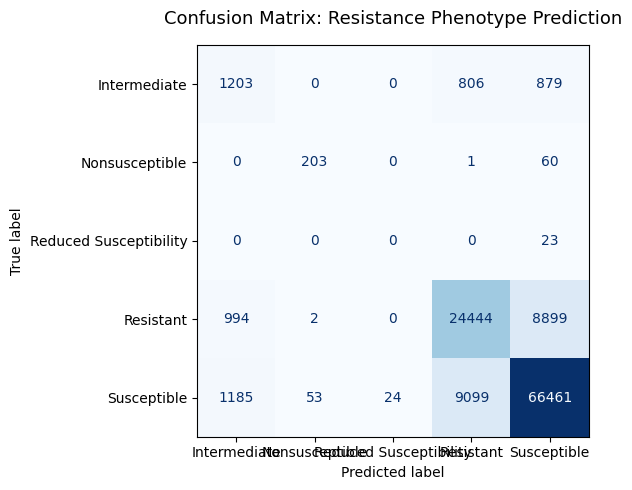

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title("Confusion Matrix: Resistance Phenotype Prediction", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# 7. Feature Importance

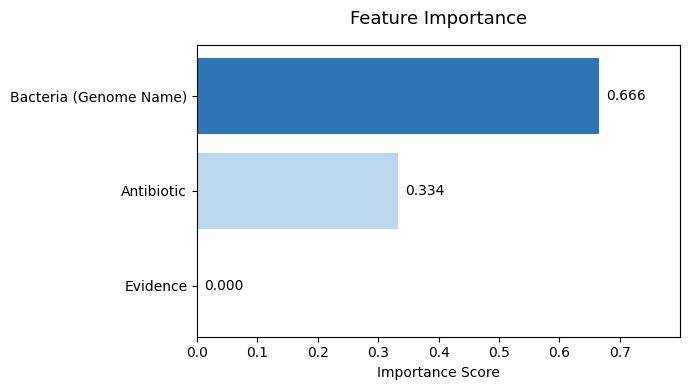

In [ ]:
importances = model.feature_importances_
features    = ['Bacteria (Genome Name)', 'Antibiotic', 'Evidence']

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2E75B6' if i == np.argmax(importances) else '#BDD7EE' for i in range(len(features))]
bars = ax.barh(features, importances, color=colors)
ax.bar_label(bars, fmt='%.3f', padding=5)
ax.set_xlim(0, max(importances) * 1.2)
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance", fontsize=13, pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()